<a href="https://colab.research.google.com/github/deepthi25p/Customer-Churn-analysis/blob/main/Churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Baza customer Telecom v2.csv')
df.head(20)

,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
0,123759242,Bronze,SOHO,6000.0,VM,2,NaN,NaN,2,40.17,0.0,40.17,NaN,No
1,126145737,Bronze,SOHO,6400.0,VM,3,NaN,NaN,3,40.17,0.0,40.17,13.39,No
2,123506355,Bronze,SOHO,6000.0,DI,2,3.0,NaN,5,40.17,0.0,40.17,20.09,No
3,112595585,Bronze,SOHO,4400.0,MT,1,2.0,NaN,3,40.17,0.0,40.17,40.17,No
4,115097935,Iron,SOHO,4000.0,AD,2,1.0,NaN,3,40.17,0.0,40.17,20.09,No
5,108684074,Gold,VSE,6600.0,RJ,2,11.0,NaN,13,40.17,0.0,40.17,20.09,No
6,112504678,Bronze,SOHO,4644.0,MT,4,NaN,NaN,4,40.33,0.0,40.33,10.08,Yes
7,833121152,Iron,SOHO,6100.0,VM,5,2.0,NaN,7,40.33,0.0,40.33,8.07,No
8,123654309,Iron,SOHO,6100.0,DI,3,NaN,NaN,3,40.33,0.0,40.33,13.44,No
9,123688980,Bronze,SOHO,6280.0,AD?,1,NaN,NaN,1,40.33,0.0,40.33,40.33,No


In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8453 entries, 0 to 8452
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PID                     8453 non-null   object 
 1   CRM_PID_Value_Segment   8448 non-null   object 
 2   EffectiveSegment        8453 non-null   object 
 3   Billing_ZIP             8451 non-null   float64
 4   KA_name                 8453 non-null   object 
 5   Active_subscribers      8453 non-null   int64  
 6   Not_Active_subscribers  4304 non-null   float64
 7   Suspended_subscribers   352 non-null    float64
 8   Total_SUBs              8453 non-null   int64  
 9   AvgMobileRevenue        8453 non-null   float64
 10  AvgFIXRevenue           8453 non-null   float64
 11  TotalRevenue            8453 non-null   float64
 12  ARPU                    8452 non-null   float64
 13  CHURN                   8453 non-null   object 
dtypes: float64(7), int64(2), object(5)
memor

In [ ]:
df.isnull().sum()

,0
PID,0
CRM_PID_Value_Segment,5
EffectiveSegment,0
Billing_ZIP,2
KA_name,0
Active_subscribers,0
Not_Active_subscribers,4149
Suspended_subscribers,8101
Total_SUBs,0
AvgMobileRevenue,0


In [ ]:
pd.set_option("display.max_columns",None)
df.head(2)

,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
0,123759242,Bronze,SOHO,6000.0,VM,2,NaN,NaN,2,40.17,0.0,40.17,NaN,No
1,126145737,Bronze,SOHO,6400.0,VM,3,NaN,NaN,3,40.17,0.0,40.17,13.39,No


In [ ]:
df['CRM_PID_Value_Segment'].fillna(df['CRM_PID_Value_Segment'].mode()[0], inplace=True)
df['Billing_ZIP'].fillna(df['Billing_ZIP'].mode()[0], inplace=True)
df['Not_Active_subscribers'].fillna(df['Not_Active_subscribers'].mode()[0], inplace=True)
df['Suspended_subscribers'].fillna(df['Suspended_subscribers'].mode()[0], inplace=True)
df['ARPU'].fillna(df['ARPU'].mode()[0],inplace=True)

/tmp/ipython-input-773147831.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CRM_PID_Value_Segment'].fillna(df['CRM_PID_Value_Segment'].mode()[0], inplace=True)
/tmp/ipython-input-773147831.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [ ]:
df.head(10)

,PID,CRM_PID_Value_Segment,EffectiveSegment,Billing_ZIP,KA_name,Active_subscribers,Not_Active_subscribers,Suspended_subscribers,Total_SUBs,AvgMobileRevenue,AvgFIXRevenue,TotalRevenue,ARPU,CHURN
0,123759242,Bronze,SOHO,6000.0,VM,2,1.0,1.0,2,40.17,0.0,40.17,14.83,No
1,126145737,Bronze,SOHO,6400.0,VM,3,1.0,1.0,3,40.17,0.0,40.17,13.39,No
2,123506355,Bronze,SOHO,6000.0,DI,2,3.0,1.0,5,40.17,0.0,40.17,20.09,No
3,112595585,Bronze,SOHO,4400.0,MT,1,2.0,1.0,3,40.17,0.0,40.17,40.17,No
4,115097935,Iron,SOHO,4000.0,AD,2,1.0,1.0,3,40.17,0.0,40.17,20.09,No
5,108684074,Gold,VSE,6600.0,RJ,2,11.0,1.0,13,40.17,0.0,40.17,20.09,No
6,112504678,Bronze,SOHO,4644.0,MT,4,1.0,1.0,4,40.33,0.0,40.33,10.08,Yes
7,833121152,Iron,SOHO,6100.0,VM,5,2.0,1.0,7,40.33,0.0,40.33,8.07,No
8,123654309,Iron,SOHO,6100.0,DI,3,1.0,1.0,3,40.33,0.0,40.33,13.44,No
9,123688980,Bronze,SOHO,6280.0,AD?,1,1.0,1.0,1,40.33,0.0,40.33,40.33,No


In [ ]:
df.isnull().sum()

,0
PID,0
CRM_PID_Value_Segment,0
EffectiveSegment,0
Billing_ZIP,0
KA_name,0
Active_subscribers,0
Not_Active_subscribers,0
Suspended_subscribers,0
Total_SUBs,0
AvgMobileRevenue,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_cols=df.select_dtypes(include="object").columns
for col in categorical_cols:
  le=LabelEncoder()
  df[col]=le.fit_transform(df[col])
X=df.drop('CHURN',axis=1)
y=df['CHURN']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)

SVC()

In [ ]:
y_pred=svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.94795978710822
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1603
           1       0.00      0.00      0.00        88

    accuracy                           0.95      1691
   macro avg       0.47      0.50      0.49      1691
weighted avg       0.90      0.95      0.92      1691

Confusion Matrix:
[[1603    0]
 [  88    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Logistic Regression
logistic_model=LogisticRegression(random_state=42)
logistic_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [ ]:
y_pred = logistic_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Classification Report:")
print(classification_rep)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.94795978710822
Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1603
           1       0.00      0.00      0.00        88

    accuracy                           0.95      1691
   macro avg       0.47      0.50      0.49      1691
weighted avg       0.90      0.95      0.92      1691

Confusion Matrix:
[[1603    0]
 [  88    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
classification_rep_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf}")
print("Random Forest Classification Report:")
print(classification_rep_rf)
print("Random Forest Confusion Matrix:")
print(conf_matrix_rf)

Random Forest Accuracy: 0.9473684210526315
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1603
           1       0.00      0.00      0.00        88

    accuracy                           0.95      1691
   macro avg       0.47      0.50      0.49      1691
weighted avg       0.90      0.95      0.92      1691

Random Forest Confusion Matrix:
[[1602    1]
 [  88    0]]


In [ ]:
#Light GBM
!pip install lightgbm


In [ ]:
import lightgbm as lgb
lgb_model=lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 461, number of negative: 6301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001121 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1467
[LightGBM] [Info] Number of data points in the train set: 6762, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.068175 -> initscore=-2.615066
[LightGBM] [Info] Start training from score -2.615066


LGBMClassifier(random_state=42)

In [ ]:
y_pred_lgb = lgb_model.predict(X_test)

accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
classification_rep_lgb = classification_report(y_test, y_pred_lgb)
conf_matrix_lgb = confusion_matrix(y_test, y_pred_lgb)

print(f"LightGBM Accuracy: {accuracy_lgb}")
print("LightGBM Classification Report:")
print(classification_rep_lgb)
print("LightGBM Confusion Matrix:")
print(conf_matrix_lgb)

LightGBM Accuracy: 0.9485511531638084
LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1603
           1       0.67      0.02      0.04        88

    accuracy                           0.95      1691
   macro avg       0.81      0.51      0.51      1691
weighted avg       0.93      0.95      0.93      1691

LightGBM Confusion Matrix:
[[1602    1]
 [  86    2]]


In [ ]:
#Gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
y_pred_gb = gb_model.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)
classification_rep_gb = classification_report(y_test, y_pred_gb)
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

print(f"Gradient Boosting Accuracy: {accuracy_gb}")
print("Gradient Boosting Classification Report:")
print(classification_rep_gb)
print("Gradient Boosting Confusion Matrix:")
print(conf_matrix_gb)

Gradient Boosting Accuracy: 0.9467770549970431
Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1603
           1       0.00      0.00      0.00        88

    accuracy                           0.95      1691
   macro avg       0.47      0.50      0.49      1691
weighted avg       0.90      0.95      0.92      1691

Gradient Boosting Confusion Matrix:
[[1601    2]
 [  88    0]]


In [ ]:
#XG boost
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [07:19:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
classification_rep_xgb = classification_report(y_test, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

print(f"XGBoost Accuracy: {accuracy_xgb}")
print("XGBoost Classification Report:")
print(classification_rep_xgb)
print("XGBoost Confusion Matrix:")
print(conf_matrix_xgb)

XGBoost Accuracy: 0.9438202247191011
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1603
           1       0.18      0.02      0.04        88

    accuracy                           0.94      1691
   macro avg       0.57      0.51      0.51      1691
weighted avg       0.91      0.94      0.92      1691

XGBoost Confusion Matrix:
[[1594    9]
 [  86    2]]


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC for SVM
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, svm_model.decision_function(X_test))
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Calculate ROC curve and AUC for Logistic Regression
fpr_logistic, tpr_logistic, thresholds_logistic = roc_curve(y_test, logistic_model.predict_proba(X_test)[:, 1])
roc_auc_logistic = auc(fpr_logistic, tpr_logistic)

# Calculate ROC curve and AUC for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Calculate ROC curve and AUC for LightGBM
fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, lgb_model.predict_proba(X_test)[:, 1])
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

# Calculate ROC curve and AUC for Gradient Boosting
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, gb_model.predict_proba(X_test)[:, 1])
roc_auc_gb = auc(fpr_gb, tpr_gb)

# Calculate ROC curve and AUC for XGBoost
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, xgb_model.predict_proba(X_test)[:, 1])
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)



In [ ]:
from sklearn.metrics import roc_auc_score

# Calculate AUC-ROC for SVM
y_pred_proba_svm = svm_model.decision_function(X_test)  # Use decision_function for SVM
auc_roc_svm = roc_auc_score(y_test, y_pred_proba_svm)
print(f"SVM AUC-ROC: {auc_roc_svm}")

# Calculate AUC-ROC for Logistic Regression
y_pred_proba_logistic = logistic_model.predict_proba(X_test)[:, 1]
auc_roc_logistic = roc_auc_score(y_test, y_pred_proba_logistic)
print(f"Logistic Regression AUC-ROC: {auc_roc_logistic}")

# Calculate AUC-ROC for Random Forest
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
auc_roc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"Random Forest AUC-ROC: {auc_roc_rf}")

# Calculate AUC-ROC for LightGBM
y_pred_proba_lgb = lgb_model.predict_proba(X_test)[:, 1]
auc_roc_lgb = roc_auc_score(y_test, y_pred_proba_lgb)
print(f"LightGBM AUC-ROC: {auc_roc_lgb}")

# Calculate AUC-ROC for Gradient Boosting
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]
auc_roc_gb = roc_auc_score(y_test, y_pred_proba_gb)
print(f"Gradient Boosting AUC-ROC: {auc_roc_gb}")

# Calculate AUC-ROC for XGBoost
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
auc_roc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"XGBoost AUC-ROC: {auc_roc_xgb}")

SVM AUC-ROC: 0.4920816083479839
Logistic Regression AUC-ROC: 0.5595757953836556
Random Forest AUC-ROC: 0.6037082459025691
LightGBM AUC-ROC: 0.5515936029036466
Gradient Boosting AUC-ROC: 0.5837066863267737
XGBoost AUC-ROC: 0.5298587875007088


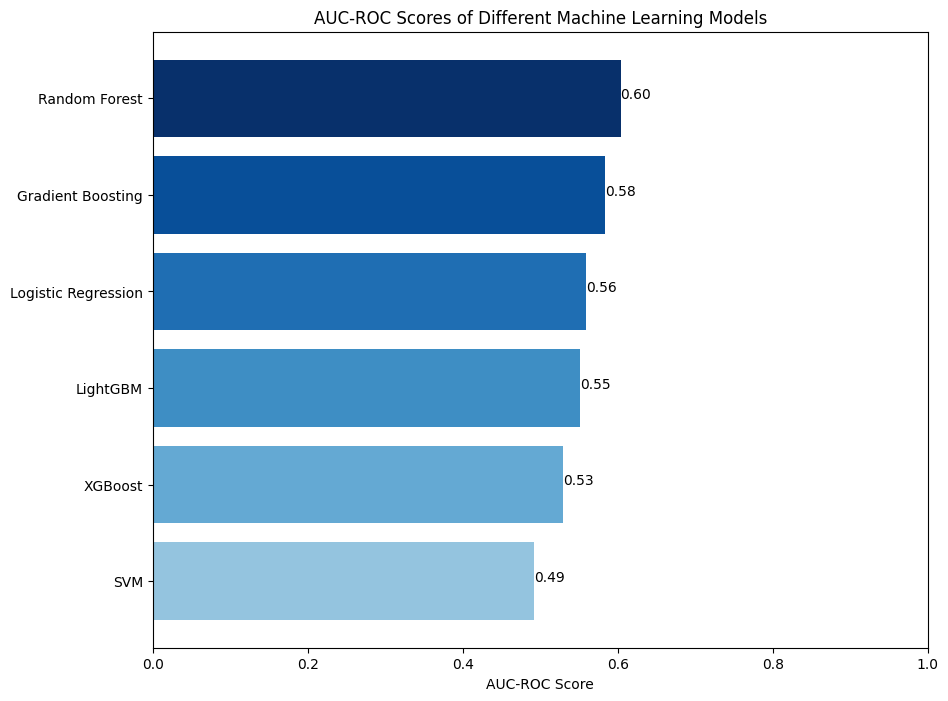

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and their corresponding AUC-ROC scores
models = ['SVM', 'Logistic Regression', 'Random Forest', 'LightGBM', 'Gradient Boosting', 'XGBoost']
auc_scores = [auc_roc_svm, auc_roc_logistic, auc_roc_rf, auc_roc_lgb, auc_roc_gb, auc_roc_xgb]

# Sort models and scores
sorted_indices = np.argsort(auc_scores)
sorted_models = [models[i] for i in sorted_indices]
sorted_auc_scores = [auc_scores[i] for i in sorted_indices]

# Create horizontal bar chart
plt.figure(figsize=(10, 8))  # Increased figure size

# Create a gradient color
colors = plt.cm.Blues(np.linspace(0.4, 1, len(sorted_models)))

plt.barh(sorted_models, sorted_auc_scores, color=colors)
plt.xlabel('AUC-ROC Score')
plt.title('AUC-ROC Scores of Different Machine Learning Models')
plt.xlim([0.0, 1.0]) # AUC-ROC scores range from 0 to 1

# Add scores at the end of bars
for index, value in enumerate(sorted_auc_scores):
    plt.text(value, index, f'{value:.2f}')

plt.show()

In [ ]:
# =========================================
# 12. MAKE PREDICTIONS FOR NEW CUSTOMERS
# =========================================

# Example: new customer details (replace values with real data)
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Initialize and fit the scaler on the training data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) # Fit scaler on the entire X data before splitting

# Split the scaled data
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


new_customer = {
    'PID': 'new_customer_id', # Example PID
    'CRM_PID_Value_Segment': 'Bronze', # Example segment
    'EffectiveSegment': 'SOHO', # Example segment
    'Billing_ZIP': 6000.0, # Example ZIP
    'KA_name': 'VM', # Example KA name
    'Active_subscribers': 2, # Example active subscribers
    'Not_Active_subscribers': 1.0, # Example not active subscribers
    'Suspended_subscribers': 1.0, # Example suspended subscribers
    'Total_SUBs': 2, # Example total subscribers
    'AvgMobileRevenue ': 40.17, # Example mobile revenue
    'AvgFIXRevenue': 0.0, # Example fix revenue
    'TotalRevenue': 40.17, # Example total revenue
    'ARPU': 14.83 # Example ARPU
}

# Convert to DataFrame
new_df = pd.DataFrame([new_customer])

# Apply label encoding to categorical features in new_df
# Only process columns that are in new_df and were in categorical_cols
categorical_cols_in_new_df = [col for col in categorical_cols if col in new_df.columns]

for col in categorical_cols_in_new_df:
    # Ensure the category exists in the original data's categories
    if new_df[col].iloc[0] in le.classes_:
        new_df[col] = le.transform(new_df[col])
    else:
        # Handle unseen categories, e.g., assign a default value or raise an error
        # For simplicity, we'll assign a value that represents an unknown category
        new_df[col] = -1 # Or some other indicator


# Ensure columns are in the same order as X
new_df = new_df[X.columns]


# Scale the new customer data
new_df_scaled = scaler.transform(new_df)

# Predict using the best model (using Random Forest based on previous AUC-ROC results)
best_model = rf_model
churn_prob = best_model.predict_proba(new_df_scaled)[:, 1][0]
churn_pred = best_model.predict(new_df_scaled)[0]

print(f"\nPredicted churn probability: {churn_prob:.2f}")
print(f"Predicted class: {'CHURN' if churn_pred==1 else 'No Churn'}")


Predicted churn probability: 0.27
Predicted class: No Churn


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
